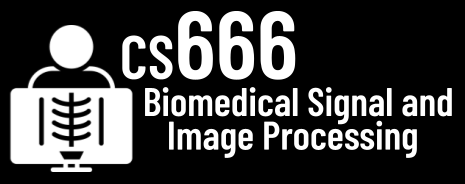
#Assignment 6

In [1]:
# NAME: Leo Navarro Mercado

In [2]:
# In this assignment, we will visualize and explore a CT scan!

In [3]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
# we are using pydicom, so lets install it!
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.2 MB/s eta 0:00:00


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [5]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [6]:
!wget https://cs666.org/data/ct.zip

--2026-05-06 04:56:01--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  --.-KB/s    in 0.02s   

2026-05-06 04:56:02 (231 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [7]:
# Then use the following snippet to extract the data.

In [8]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [9]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [10]:
# 220 slices

In [11]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [12]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

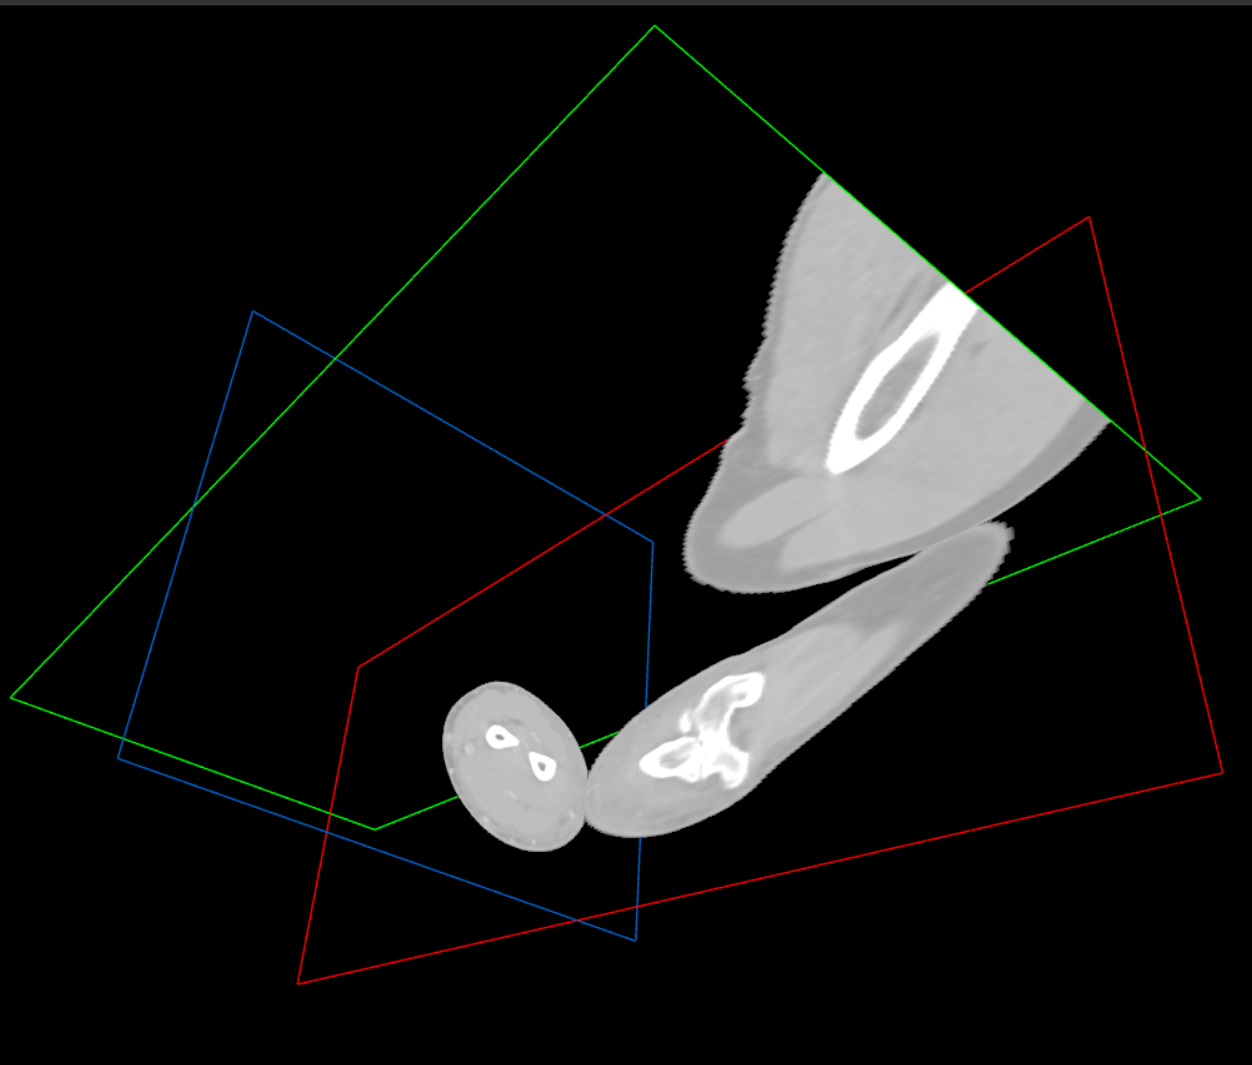

In [13]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [14]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

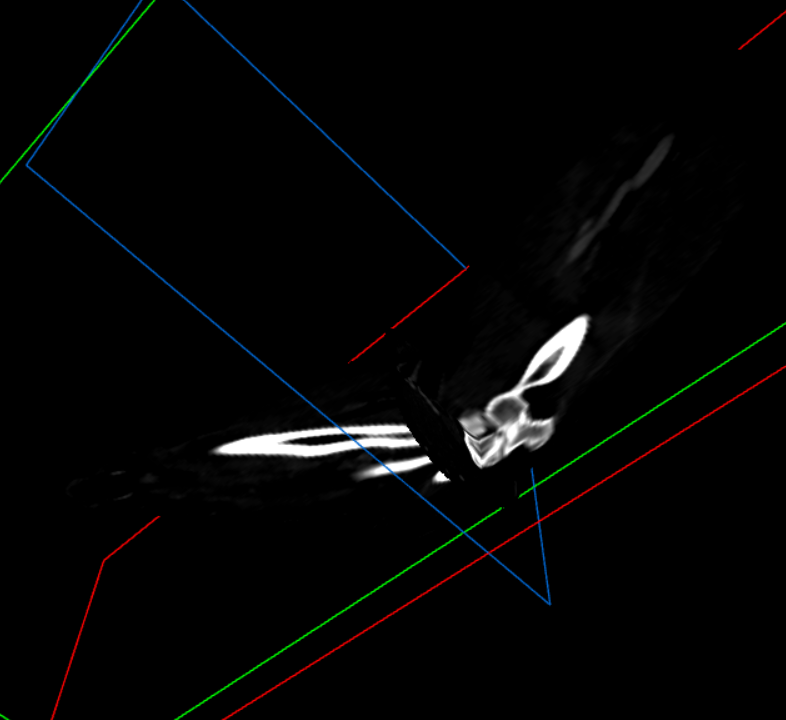

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [15]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [16]:
from pydicom import dcmread
import os
import numpy as np

In [17]:
files = sorted(os.listdir('ct'))
print(len(files))
print(files[0], files[-1])

slices = []
for file in files:
    filepath = os.path.join('ct', file)
    ds = dcmread(filepath)
    slices.append(ds.pixel_array)

ct_volume = np.stack(slices, axis=0)
print(ct_volume.shape)

220
IM-0001-0001.dcm IM-0001-0220.dcm
(220, 454, 512)


In [18]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

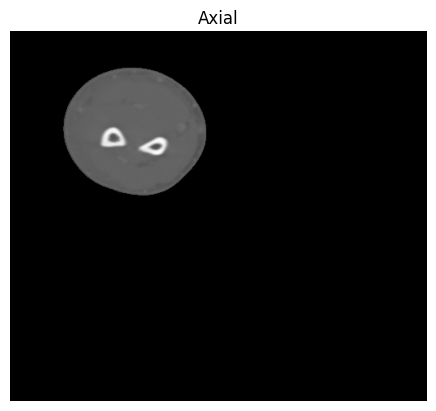

In [19]:
plt.figure()
plt.imshow(ct_volume[110, :, :], cmap='gray')
plt.title('Axial')
plt.axis('off')
plt.show()

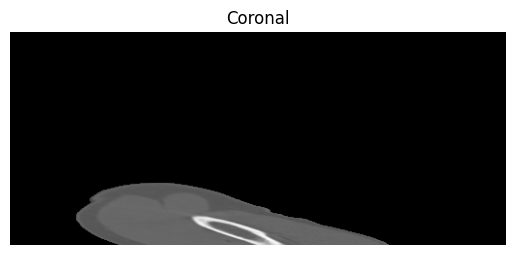

In [20]:
plt.figure()
plt.imshow(ct_volume[:, 227, :], cmap='gray')
plt.title('Coronal')
plt.axis('off')
plt.show()

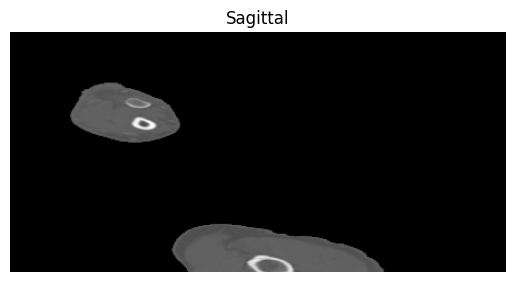

In [21]:
plt.figure()
plt.imshow(ct_volume[:, :, 256], cmap='gray')
plt.title('Sagittal')
plt.axis('off')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [22]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [23]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.


vmin: -175.0, vmax: 235.0


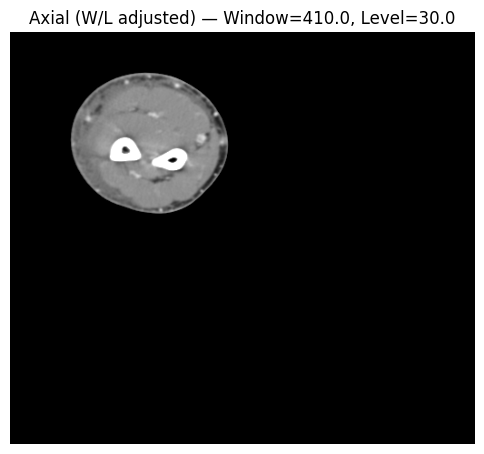

In [24]:
# Load one slice to extract Window/Level and Rescale values
sample = dcmread(os.path.join('ct', files[len(files)//2]))

# Extract Window/Level and Rescale Intercept from DICOM header
level   = sample[0x0028, 0x1050].value  # Window Center
window  = sample[0x0028, 0x1051].value  # Window Width
rescale = sample[0x0028, 0x1052].value  # Rescale Intercept

level   = float(level)
window  = float(window)
rescale = float(rescale)

# Compute vmin/vmax
vmin = level - window / 2
vmax = level + window / 2

print(f"\nvmin: {vmin}, vmax: {vmax}")

# Visualize the middle axial slice with Window/Level adjustment
mid = ct_volume.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(ct_volume[mid, :, :] + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f'Axial (W/L adjusted) — Window={window}, Level={level}')
plt.axis('off')
plt.show()

In [25]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

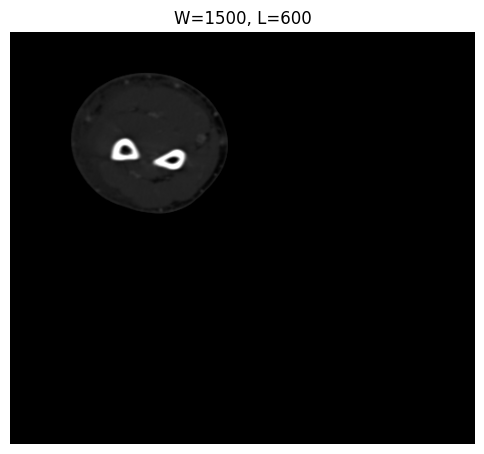

In [36]:
from ipywidgets import interact, IntSlider

mid = ct_volume.shape[0] // 2
hu_slice = ct_volume[mid, :, :] + rescale

def show_slice(window, level):
    plt.figure(figsize=(6, 6))
    plt.imshow(hu_slice, cmap='gray', vmin=level - window/2, vmax=level + window/2)
    plt.title(f'W={window}, L={level}')
    plt.axis('off')
    plt.show()

show_slice(1500, 600)

In [27]:
# Which values make sense and why?

In [28]:
# It depends on what you're trying to look at. For example if you want to
# look/focus on bones then you would put a window value of ~1500 and a level value of around ~600

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [29]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

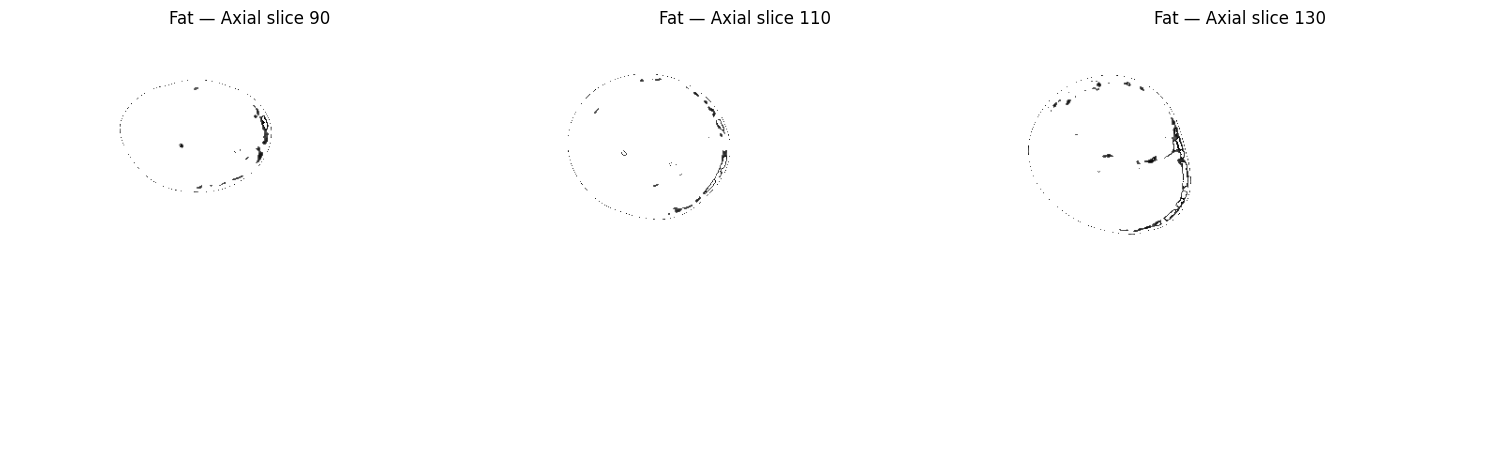

In [30]:
hu_volume = ct_volume.astype(np.int16) + int(rescale)

fat_mask = hu_volume.copy()
fat_mask[fat_mask < -100] = 0
fat_mask[fat_mask > -60]  = 0

mid = fat_mask.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, offset in enumerate([-20, 0, 20]):
    axes[i].imshow(fat_mask[mid + offset, :, :], cmap='gray')
    axes[i].set_title(f'Fat — Axial slice {mid + offset}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

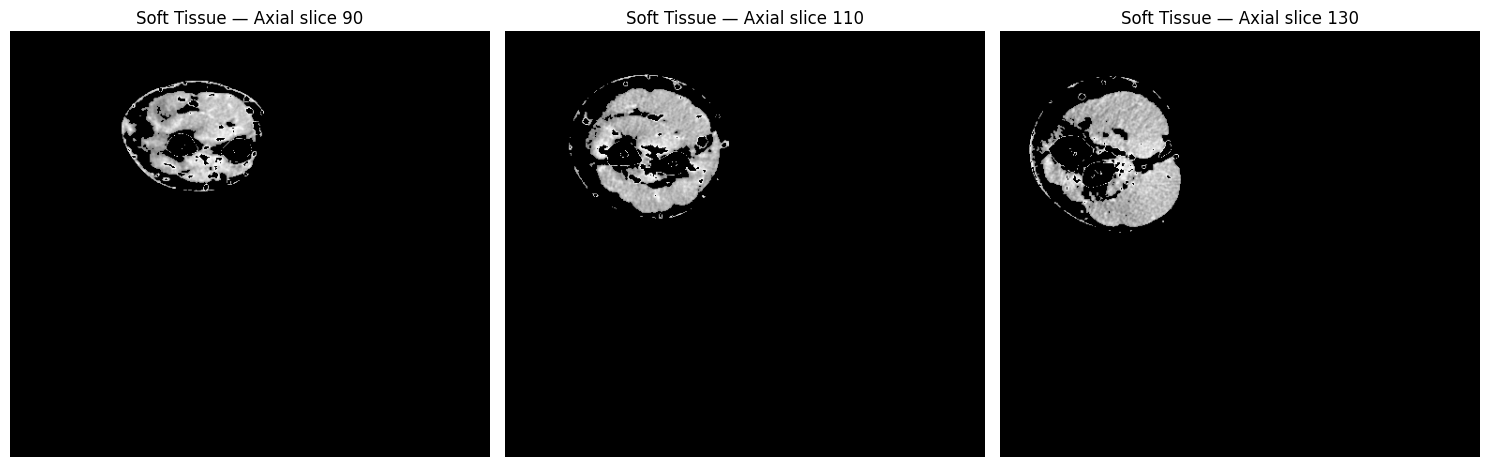

In [31]:
soft_mask = hu_volume.copy()
soft_mask[soft_mask < 40] = 0
soft_mask[soft_mask > 80] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, offset in enumerate([-20, 0, 20]):
    axes[i].imshow(soft_mask[mid + offset, :, :], cmap='gray')
    axes[i].set_title(f'Soft Tissue — Axial slice {mid + offset}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

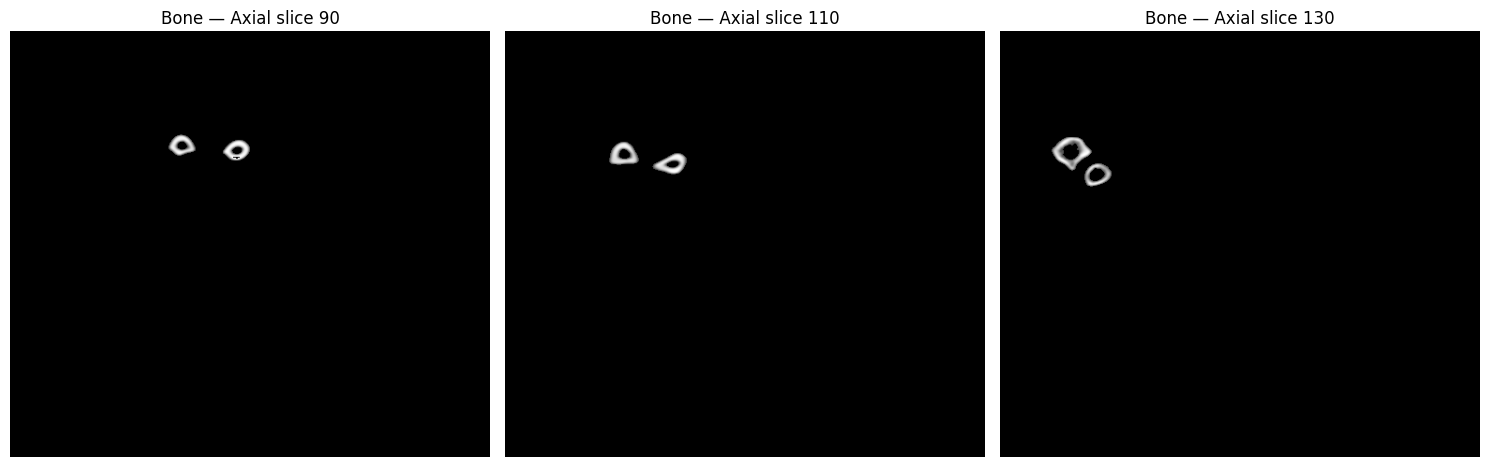

In [32]:
bone_mask = hu_volume.copy()
bone_mask[bone_mask < 400]  = 0
bone_mask[bone_mask > 1800] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, offset in enumerate([-20, 0, 20]):
    axes[i].imshow(bone_mask[mid + offset, :, :], cmap='gray')
    axes[i].set_title(f'Bone — Axial slice {mid + offset}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [33]:
# Are the segmentations good?

In [34]:
# They do seem to do the job, although for fat you do need to look at it with the colors inverted

In [35]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""